# Single-GPU Transformer Training

## Scaling a DNA Sequence Model with Mixed Precision, Checkpointing, Accumulation & Layer Scanning

**Scenario**: A computational genomics lab is training a **transformer language model** on DNA sequences to learn nucleotide patterns in regulatory regions. The model predicts the next nucleotide in a sequence, capturing motifs like TATA boxes and GC-rich regions. The model is too large for memory-constrained hardware at full batch size.

We integrate **four GPU optimization techniques** into a single transformer architecture, all toggled via configuration:

| Technique | Config key | What it does | Trade-off |
|-----------|-----------|-------------|-----------|
| **Mixed Precision** | `dtype=bfloat16` | Half-precision activations, float32 params | ~2× memory savings, faster on GPU/TPU |
| **Gradient Checkpointing** | `remat=("MLP","Attn")` | Discard & recompute activations in backward | Memory ↓↓, compute ↑ ~30% |
| **Gradient Accumulation** | `num_minibatches=K` | Average gradients over K sub-batches | Simulates large batch in small memory |
| **Layer Scanning** | `scan_layers=True` | Share compiled code across layers via `nn.scan` | Compilation time ↓, slight speed overhead |

Based on the [UvA DLC Single-GPU Transformer tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/scaling/JAX/single_gpu_transformer.html).

In [1]:
import functools
from typing import Any, Dict, Tuple, NamedTuple
from types import SimpleNamespace

import flax.linen as nn
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
import matplotlib as mpl
import time

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

JAX version: 0.9.0.1
Devices: [CpuDevice(id=0)]


---

## 1 — DNA Sequence Data

We generate synthetic DNA sequences for **next-nucleotide prediction** (causal language modeling). Each sequence is a string of nucleotides (A, C, G, T) encoded as integers.

The vocabulary is minimal — just 5 tokens — but the architecture and training techniques are identical to those used for large-scale language models.

In [2]:
class Batch(NamedTuple):
    """Container for a batch of data (NamedTuple = automatic JAX pytree)."""
    inputs: jax.Array
    labels: jax.Array


# --- DNA vocabulary ---
VOCAB = {0: '<pad>', 1: 'A', 2: 'C', 3: 'G', 4: 'T'}
VOCAB_SIZE = 5
SEQ_LEN = 64
BATCH_SIZE = 64

# --- Generate random DNA sequences ---
key = jax.random.PRNGKey(42)
key, seq_key = jax.random.split(key)

# Random nucleotide sequences (integers 1-4)
tokens = jax.random.randint(seq_key, (BATCH_SIZE, SEQ_LEN), 1, VOCAB_SIZE)

# Causal LM format: input = [PAD, t₀, t₁, ...], labels = [t₀, t₁, t₂, ...]
batch = Batch(
    inputs=jnp.pad(tokens[:, :-1], ((0, 0), (1, 0)), constant_values=0),
    labels=tokens,
)

print(f"Batch shape: inputs {batch.inputs.shape}, labels {batch.labels.shape}")
print(f"Vocabulary: {VOCAB}")
print(f"Example sequence: {''.join(VOCAB[int(t)] for t in tokens[0, :30])}...")

Batch shape: inputs (64, 64), labels (64, 64)
Vocabulary: {0: '<pad>', 1: 'A', 2: 'C', 3: 'G', 4: 'T'}
Example sequence: CAAATACGATAAATCACGCTTGGAGAGGGC...


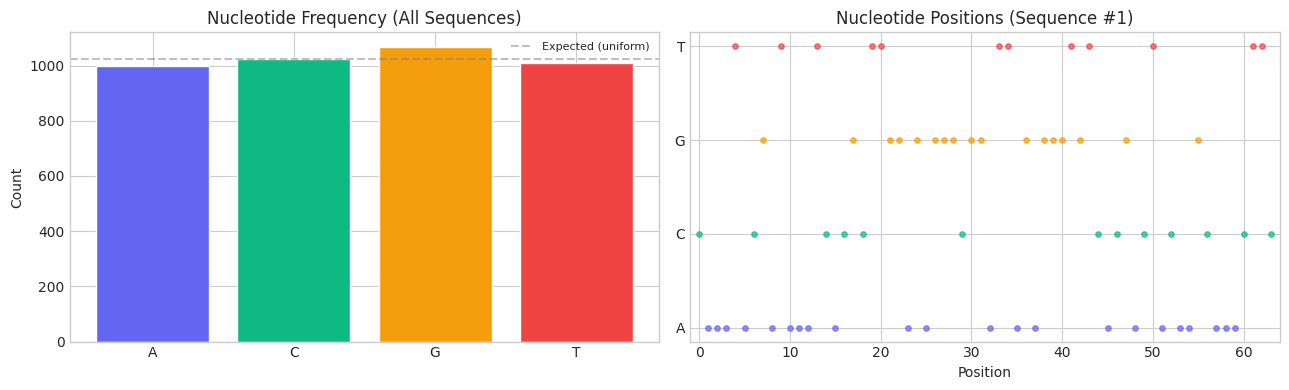

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ["#6366f1", "#10b981", "#f59e0b", "#ef4444"]
nuc_names = ['A', 'C', 'G', 'T']

# Nucleotide frequency distribution
nuc_counts = [int((tokens == i + 1).sum()) for i in range(4)]
axes[0].bar(nuc_names, nuc_counts, color=colors, edgecolor="white")
axes[0].set_ylabel("Count")
axes[0].set_title("Nucleotide Frequency (All Sequences)")
axes[0].axhline(y=BATCH_SIZE * SEQ_LEN / 4, color='gray', linestyle='--',
                alpha=0.5, label='Expected (uniform)')
axes[0].legend(fontsize=8)

# Positional nucleotide distribution (first sequence)
seq = np.array(tokens[0])
positions = np.arange(SEQ_LEN)
for i, (name, color) in enumerate(zip(nuc_names, colors)):
    mask = seq == (i + 1)
    axes[1].scatter(positions[mask], [i] * mask.sum(), color=color,
                    s=15, alpha=0.7, label=name)
axes[1].set_xlabel("Position")
axes[1].set_yticks(range(4))
axes[1].set_yticklabels(nuc_names)
axes[1].set_title("Nucleotide Positions (Sequence #1)")
axes[1].set_xlim(-1, SEQ_LEN)

plt.tight_layout()
plt.show()

---

## 2 — Transformer Architecture

The model is a **decoder-only transformer** (GPT-style) with all four optimization techniques built into the architecture, controlled by a configuration object:

- **`dtype`**: controls activation precision (float32 or bfloat16)
- **`remat`**: tuple of block names to checkpoint (`"MLP"`, `"Attn"`, `"Block"`)
- **`scan_layers`**: whether to use `nn.scan` to share compiled code across layers
- Gradient accumulation is handled externally in the training step

### Numerically Stable Attention

The softmax computation is always performed in **float32** regardless of the model's activation dtype, preventing overflow/underflow in mixed-precision training:

$$\text{Attention}(Q, K, V) = \text{softmax}_{\text{float32}}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

In [4]:
def dot_product_attention(
    query: jax.Array,
    key: jax.Array,
    value: jax.Array,
    mask: jax.Array | None = None,
    softmax_dtype: jnp.dtype = jnp.float32,
) -> jax.Array:
    """Scaled dot-product attention with float32 softmax for numerical stability.

    Casts Q/K to float32 before softmax to prevent overflow in bfloat16 mode.
    After softmax, casts back to the original dtype for the value projection.
    """
    num_features = query.shape[-1]
    dtype = query.dtype
    query = query * (num_features ** -0.5)

    # Upcast for numerical stability
    query = query.astype(softmax_dtype)
    key = key.astype(softmax_dtype)
    weights = jnp.einsum("...qhd,...khd->...hqk", query, key)

    if mask is not None:
        weights = jnp.where(mask, weights, jnp.finfo(softmax_dtype).min)

    weights = nn.softmax(weights, axis=-1).astype(dtype)
    new_vals = jnp.einsum("...hqk,...khd->...qhd", weights, value)
    return new_vals.astype(dtype)

In [5]:
class MLPBlock(nn.Module):
    """Feed-forward block with pre-norm, GELU activation, and configurable precision."""
    config: Any
    train: bool

    @nn.compact
    def __call__(self, x: jax.Array) -> jax.Array:
        features = x.shape[-1]
        x = nn.LayerNorm(dtype=self.config.dtype, name="pre_norm")(x)
        x = nn.Dense(self.config.mlp_expansion * features,
                     dtype=self.config.dtype, name="up_proj")(x)
        x = nn.gelu(x)
        x = nn.Dense(features, dtype=self.config.dtype, name="down_proj")(x)
        x = nn.Dropout(rate=self.config.dropout_rate, deterministic=not self.train)(x)
        return x


class AttentionBlock(nn.Module):
    """Multi-head attention with pre-norm and stable softmax."""
    config: Any
    mask: jax.Array | None
    train: bool

    @nn.compact
    def __call__(self, x: jax.Array) -> jax.Array:
        features = x.shape[-1]
        x = nn.LayerNorm(dtype=self.config.dtype, name="pre_norm")(x)
        # Single projection for Q, K, V
        qkv = nn.DenseGeneral(
            features=(self.config.num_heads, self.config.head_dim * 3),
            dtype=self.config.dtype, name="qkv",
        )(x)
        q, k, v = jnp.split(qkv, 3, axis=-1)
        x = dot_product_attention(q, k, v, mask=self.mask,
                                  softmax_dtype=self.config.softmax_dtype)
        x = nn.DenseGeneral(features=features, axis=(-2, -1),
                            dtype=self.config.dtype, name="out_proj")(x)
        x = nn.Dropout(rate=self.config.dropout_rate, deterministic=not self.train)(x)
        return x

In [6]:
class TransformerBlock(nn.Module):
    """Single transformer layer: Attention + MLP with residual connections.

    Each sub-block can be independently wrapped with nn.remat for gradient
    checkpointing, controlled by config.remat.
    """
    config: Any
    mask: jax.Array | None
    train: bool

    @nn.compact
    def __call__(self, x: jax.Array) -> jax.Array:
        # Attention with optional rematerialization
        attn = AttentionBlock
        if "Attn" in self.config.remat:
            attn = nn.remat(attn, prevent_cse=False)
        x = x + attn(config=self.config, mask=self.mask,
                      train=self.train, name="attn")(x)

        # MLP with optional rematerialization
        mlp = MLPBlock
        if "MLP" in self.config.remat:
            mlp = nn.remat(mlp, prevent_cse=False)
        x = x + mlp(config=self.config, train=self.train, name="mlp")(x)
        return x


class Transformer(nn.Module):
    """Decoder-only transformer with configurable scaling techniques.

    Supports:
    - Mixed precision via config.dtype
    - Gradient checkpointing via config.remat
    - Layer scanning via config.scan_layers
    """
    config: Any

    @nn.compact
    def __call__(self, x: jax.Array, mask: jax.Array | None = None,
                 train: bool = True) -> jax.Array:
        # Causal mask for autoregressive generation
        if mask is None and self.config.causal_mask:
            mask = nn.make_causal_mask(x, dtype=jnp.bool_)

        # Token + positional embeddings
        x = nn.Embed(self.config.vocab_size, self.config.hidden_size,
                      dtype=self.config.dtype, name="embed")(x)
        pos_emb = self.param(
            "pos_emb",
            nn.initializers.normal(stddev=0.02),
            (self.config.max_seq_len, self.config.hidden_size),
        )
        x = x + pos_emb.astype(self.config.dtype)[None, :x.shape[1]]

        # Transformer blocks — scanned or unrolled
        block_fn = functools.partial(
            TransformerBlock, config=self.config, mask=mask, train=train
        )
        if "Block" in self.config.remat:
            block_fn = nn.remat(block_fn, prevent_cse=False)

        if self.config.scan_layers:
            block = block_fn(name="block")
            x, _ = nn.scan(
                lambda module, carry, _: (module(carry), None),
                variable_axes={"params": 0},
                split_rngs={"params": True, "dropout": True},
                length=self.config.num_layers,
            )(block, x, ())
        else:
            for i in range(self.config.num_layers):
                x = block_fn(name=f"block_{i}")(x)

        # Output head
        x = nn.LayerNorm(dtype=self.config.dtype, name="post_norm")(x)
        x = nn.Dense(self.config.num_outputs, dtype=self.config.dtype,
                     name="lm_head")(x)
        return x.astype(jnp.float32)  # always float32 for loss computation

---

## 3 — Configuration

All scaling techniques are controlled through a single configuration object. This makes it easy to compare different setups by changing one field at a time.

In [7]:
def make_config(
    # Model
    hidden_size=128,
    num_layers=4,
    head_dim=32,
    mlp_expansion=4,
    dropout_rate=0.0,
    # Precision
    dtype=jnp.bfloat16,
    softmax_dtype=jnp.float32,
    # Scaling techniques
    remat=("MLP", "Attn"),
    scan_layers=False,
    # Training
    num_minibatches=1,
    learning_rate=3e-4,
):
    """Create a configuration namespace with derived fields."""
    num_heads = hidden_size // head_dim
    return SimpleNamespace(
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_heads=num_heads,
        head_dim=head_dim,
        mlp_expansion=mlp_expansion,
        dropout_rate=dropout_rate,
        dtype=dtype,
        softmax_dtype=softmax_dtype,
        remat=remat,
        scan_layers=scan_layers,
        vocab_size=VOCAB_SIZE,
        num_outputs=VOCAB_SIZE,
        max_seq_len=SEQ_LEN,
        causal_mask=True,
        num_minibatches=num_minibatches,
        learning_rate=learning_rate,
    )


# Default config with all techniques enabled
config = make_config()

# Quick model check
model = Transformer(config=config)
key, init_key = jax.random.split(key)
small_batch = batch.inputs[:2]
variables = model.init(init_key, small_batch, train=False)
params = variables["params"]

n_params = sum(np.prod(x.shape) for x in jax.tree.leaves(params))
print(f"Parameters: {n_params:,}")
print(f"Config: hidden={config.hidden_size}, layers={config.num_layers}, "
      f"heads={config.num_heads}, head_dim={config.head_dim}")
print(f"Techniques: dtype={config.dtype}, remat={config.remat}, "
      f"scan={config.scan_layers}, minibatches={config.num_minibatches}")

Parameters: 802,821
Config: hidden=128, layers=4, heads=4, head_dim=32
Techniques: dtype=<class 'jax.numpy.bfloat16'>, remat=('MLP', 'Attn'), scan=False, minibatches=1


---

## 4 — Training Pipeline

The pipeline combines all techniques:

1. **Loss function** computes next-token cross-entropy in float32
2. **Gradient accumulation** splits the batch into $K$ mini-batches and averages gradients:

$$\nabla_\theta \mathcal{L} = \frac{1}{K}\sum_{k=1}^{K} \nabla_\theta \mathcal{L}(\text{minibatch}_k)$$

3. **Buffer donation** reuses input memory for outputs (`donate_argnames`)
4. **JIT compilation** with static argument for `num_minibatches`

In [8]:
from flax.training import train_state


class TrainState(train_state.TrainState):
    """Extended TrainState that carries an RNG key for dropout."""
    rng: jax.Array


def next_token_loss(
    params: Any,
    apply_fn: Any,
    batch: Batch,
    rng: jax.Array,
) -> Tuple[jax.Array, Dict]:
    """Next-token prediction loss with metrics."""
    logits = apply_fn({"params": params}, batch.inputs, train=True,
                      rngs={"dropout": rng})
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, batch.labels)
    correct = jnp.equal(jnp.argmax(logits, axis=-1), batch.labels)
    batch_size = np.prod(batch.labels.shape)
    metrics = {
        "loss": (loss.sum(), batch_size),
        "accuracy": (correct.sum(), batch_size),
    }
    return loss.mean(), metrics

In [9]:
def accumulate_gradients(
    state: TrainState,
    batch: Batch,
    rng: jax.Array,
    num_minibatches: int,
    loss_fn,
) -> Tuple[Any, Dict]:
    """Accumulate gradients over mini-batches using jax.lax.scan.

    This compiles a single loop body and reuses it — more efficient than
    a Python loop which compiles separate graphs per mini-batch.
    """
    batch_size = batch.inputs.shape[0]
    minibatch_size = batch_size // num_minibatches
    rngs = jax.random.split(rng, num_minibatches)
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    def _minibatch_step(minibatch_idx):
        mb = Batch(
            inputs=jax.lax.dynamic_slice_in_dim(
                batch.inputs, minibatch_idx * minibatch_size,
                minibatch_size, axis=0),
            labels=jax.lax.dynamic_slice_in_dim(
                batch.labels, minibatch_idx * minibatch_size,
                minibatch_size, axis=0),
        )
        (_, step_metrics), step_grads = grad_fn(
            state.params, state.apply_fn, mb, rngs[minibatch_idx]
        )
        return step_grads, step_metrics

    def _scan_step(carry, minibatch_idx):
        grads, metrics = _minibatch_step(minibatch_idx)
        carry = jax.tree.map(jnp.add, carry, (grads, metrics))
        return carry, None

    # Initialize accumulators with zeros
    init_shapes = jax.eval_shape(_minibatch_step, 0)
    init = jax.tree.map(lambda x: jnp.zeros(x.shape, x.dtype), init_shapes)

    (grads, metrics), _ = jax.lax.scan(
        _scan_step, init=init,
        xs=jnp.arange(num_minibatches), length=num_minibatches,
    )
    grads = jax.tree.map(lambda g: g / num_minibatches, grads)
    return grads, metrics


print("Gradient accumulation ready (scan-based).")

Gradient accumulation ready (scan-based).


In [10]:
def make_train_step(num_minibatches):
    """Create a JIT-compiled train step for a given number of minibatches."""

    @functools.partial(jax.jit, donate_argnames=("state", "metrics"))
    def train_step(
        state: TrainState,
        metrics: Dict | None,
        batch: Batch,
    ) -> Tuple[TrainState, Dict]:
        rng, step_rng = jax.random.split(state.rng)

        grads, step_metrics = accumulate_gradients(
            state, batch, step_rng, num_minibatches,
            loss_fn=next_token_loss,
        )

        new_state = state.apply_gradients(grads=grads, rng=rng)

        if metrics is None:
            metrics = step_metrics
        else:
            metrics = jax.tree.map(jnp.add, metrics, step_metrics)
        return new_state, metrics

    return train_step


@jax.jit
def eval_step(state: TrainState, batch: Batch) -> Dict:
    """Evaluate model on a batch (no dropout)."""
    logits = state.apply_fn({"params": state.params}, batch.inputs, train=False)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, batch.labels)
    correct = jnp.equal(jnp.argmax(logits, axis=-1), batch.labels)
    batch_size = np.prod(batch.labels.shape)
    return {
        "loss": (loss.sum(), batch_size),
        "accuracy": (correct.sum(), batch_size),
    }


def compute_metrics(metrics):
    """Convert (sum, count) pairs to averages."""
    return {k: float(v[0]) / float(v[1]) for k, v in metrics.items()}


print("Train/eval steps ready.")

Train/eval steps ready.


In [11]:
def train_model(cfg, num_epochs=50, label=""):
    """Full training loop for a given configuration. Returns history dict."""
    global key

    # Create model and state
    model = Transformer(config=cfg)
    optimizer = optax.adam(
        learning_rate=optax.warmup_exponential_decay_schedule(
            init_value=0, peak_value=cfg.learning_rate,
            warmup_steps=5, transition_steps=1, decay_rate=0.99,
        )
    )

    key, init_key, state_key = jax.random.split(key, 3)
    init_batch = batch.inputs[:BATCH_SIZE // max(cfg.num_minibatches, 1)]
    params = model.init(init_key, init_batch, train=False)["params"]
    state = TrainState.create(
        apply_fn=model.apply, params=params, tx=optimizer, rng=state_key,
    )

    n_params = sum(np.prod(x.shape) for x in jax.tree.leaves(state.params))
    train_step = make_train_step(cfg.num_minibatches)

    history = {"train_loss": [], "train_acc": []}

    # Warmup (JIT compilation)
    state, _ = train_step(state, None, batch)

    t_start = time.perf_counter()
    for epoch in range(num_epochs):
        state, train_metrics = train_step(state, None, batch)
        tm = compute_metrics(train_metrics)
        history["train_loss"].append(tm["loss"])
        history["train_acc"].append(tm["accuracy"])

        if epoch % (num_epochs // 4) == 0 or epoch == num_epochs - 1:
            print(f"  Epoch {epoch:4d} | loss: {tm['loss']:.4f}  acc: {tm['accuracy']:.4f}")

    elapsed = time.perf_counter() - t_start
    history["elapsed"] = elapsed
    history["label"] = label
    history["n_params"] = n_params
    print(f"  {label} — {num_epochs} epochs in {elapsed:.2f}s "
          f"({elapsed/num_epochs*1000:.1f}ms/epoch, {n_params:,} params)")
    return history

---

## 5 — Technique 1: Mixed Precision (bfloat16)

**bfloat16** uses 8 exponent bits (same range as float32) but only 7 mantissa bits. Unlike float16, it doesn't need loss scaling — the wide exponent range prevents underflow:

| Format | Exponent | Mantissa | Range | Memory |
|--------|----------|----------|-------|--------|
| float32 | 8 bits | 23 bits | ±3.4×10³⁸ | 4 bytes |
| float16 | 5 bits | 10 bits | ±6.5×10⁴ | 2 bytes |
| **bfloat16** | **8 bits** | **7 bits** | **±3.4×10³⁸** | **2 bytes** |

In our model, **parameters are stored in float32** for precise weight updates, while **activations are computed in bfloat16**. The softmax in attention always uses float32.

In [12]:
# Demonstrate precision differences
x = jnp.array(0.1)
print(f"float32:  {x}  (23-bit mantissa)")
print(f"bfloat16: {x.astype(jnp.bfloat16)}  (7-bit mantissa → coarser)")
print(f"float16:  {x.astype(jnp.float16)}  (10-bit mantissa)")

# Dynamic range advantage
big = jnp.array(1e30)
print(f"\nLarge value (1e30):")
print(f"  bfloat16: {big.astype(jnp.bfloat16)}  ✓ (8-bit exponent)")
print(f"  float16:  {big.astype(jnp.float16)}  ✗ (5-bit exponent → overflow)")

# Verify our model's behavior
cfg_f32 = make_config(dtype=jnp.float32)
cfg_bf16 = make_config(dtype=jnp.bfloat16)
model_f32 = Transformer(config=cfg_f32)
model_bf16 = Transformer(config=cfg_bf16)

key, k1, k2 = jax.random.split(key, 3)
p_f32 = model_f32.init(k1, batch.inputs[:1], train=False)
p_bf16 = model_bf16.init(k2, batch.inputs[:1], train=False)

print(f"\nParameter dtypes (always float32):")
print(f"  float32 model: {set(p.dtype for p in jax.tree.leaves(p_f32['params']))}")
print(f"  bfloat16 model: {set(p.dtype for p in jax.tree.leaves(p_bf16['params']))}")

float32:  0.10000000149011612  (23-bit mantissa)
bfloat16: 0.100098  (7-bit mantissa → coarser)
float16:  0.0999755859375  (10-bit mantissa)

Large value (1e30):
  bfloat16: 1.00026e+30  ✓ (8-bit exponent)
  float16:  inf  ✗ (5-bit exponent → overflow)

Parameter dtypes (always float32):
  float32 model: {dtype('float32')}
  bfloat16 model: {dtype('float32')}


---

## 6 — Technique 2: Gradient Checkpointing (remat)

During backpropagation, JAX stores all intermediate activations from the forward pass. For deep transformers, this dominates memory.

`jax.remat` **discards intermediate activations** during forward and **recomputes them** during backward:

- **Without remat**: store $Q, K, V$, attention weights, MLP intermediates → $O(L \cdot d)$ memory
- **With remat**: store only layer inputs, recompute during backward → $O(d)$ per layer

Our model supports three levels of checkpointing via `config.remat`:
- `("MLP",)` — checkpoint MLP blocks only
- `("Attn",)` — checkpoint attention blocks only
- `("MLP", "Attn")` — checkpoint both (maximum savings)
- `("Block",)` — checkpoint entire transformer blocks

In [13]:
# Demonstrate remat behavior — the activation function runs twice
def tracked_gelu(x):
    """GELU that prints when executed."""
    jax.debug.print("  GELU forward executed")
    return nn.gelu(x)


def demo_loss(x, use_remat=False):
    fn = tracked_gelu
    if use_remat:
        fn = jax.remat(tracked_gelu)
    return jnp.mean(fn(x))


x_demo = jnp.ones(4)

print("WITHOUT remat (activations cached):")
_ = jax.grad(demo_loss)(x_demo, use_remat=False)

print("\nWITH remat (activations recomputed during backward):")
_ = jax.grad(demo_loss)(x_demo, use_remat=True)

print("\n→ With remat, GELU runs twice: once forward, once during backward.")

WITHOUT remat (activations cached):
  GELU forward executed

WITH remat (activations recomputed during backward):
  GELU forward executed
  GELU forward executed

→ With remat, GELU runs twice: once forward, once during backward.


---

## 7 — Technique 3: Gradient Accumulation

When the full batch doesn't fit in GPU memory, we split it into $K$ **mini-batches**, compute gradients for each, and **average** before updating:

$$\nabla_\theta \mathcal{L}_{\text{accum}} = \frac{1}{K} \sum_{k=1}^{K} \nabla_\theta \mathcal{L}(\text{minibatch}_k)$$

This is **mathematically equivalent** to computing the gradient on the full batch (no batch normalization in our model). We implement this with `jax.lax.scan` which:

- Compiles a **single loop body** (unlike a Python loop which compiles $K$ separate graphs)
- Uses `dynamic_slice_in_dim` to extract each mini-batch without copies

In [14]:
# Verify: accumulated gradients ≈ full-batch gradients
cfg_check = make_config(dtype=jnp.float32, remat=(), scan_layers=False)
model_check = Transformer(config=cfg_check)
key, k1, k2 = jax.random.split(key, 3)
params_check = model_check.init(k1, batch.inputs[:2], train=False)["params"]
state_check = TrainState.create(
    apply_fn=model_check.apply, params=params_check,
    tx=optax.adam(1e-3), rng=k2,
)

rng_check = jax.random.PRNGKey(99)

# Full batch (1 minibatch)
grads_full, _ = accumulate_gradients(
    state_check, batch, rng_check, num_minibatches=1, loss_fn=next_token_loss,
)
# Accumulated (4 minibatches)
grads_accum, _ = accumulate_gradients(
    state_check, batch, rng_check, num_minibatches=4, loss_fn=next_token_loss,
)

max_diff = max(
    float(jnp.max(jnp.abs(g1 - g2)))
    for g1, g2 in zip(jax.tree.leaves(grads_full), jax.tree.leaves(grads_accum))
)
print(f"Max |full_batch_grad - accumulated_grad|: {max_diff:.2e}")
print(f"Mathematically equivalent: {max_diff < 1e-5} ✓")

Max |full_batch_grad - accumulated_grad|: 2.98e-07
Mathematically equivalent: True ✓


---

## 8 — Technique 4: Layer Scanning

For deep transformers with **identical layer structure**, `nn.scan` shares compiled code across layers instead of unrolling them:

**Unrolled** (`scan_layers=False`):
- Each layer compiles independently → $O(L)$ compilation time and program size
- Slightly faster execution (XLA can optimize across layers)
- Better for shallow models (< 12 layers)

**Scanned** (`scan_layers=True`):
- Single layer compiled, executed $L$ times via `lax.scan` → $O(1)$ compilation
- Adds `dynamic_update_slice` overhead per layer
- Essential for very deep models (50+ layers) to keep compilation tractable

With scanning, parameters get an extra leading dimension `[num_layers, ...]` and are indexed per iteration.

In [15]:
# Compare parameter shapes: scanned vs unrolled
cfg_scan = make_config(scan_layers=True)
cfg_noscan = make_config(scan_layers=False)

model_scan = Transformer(config=cfg_scan)
model_noscan = Transformer(config=cfg_noscan)

key, k1, k2 = jax.random.split(key, 3)
p_scan = model_scan.init(k1, batch.inputs[:1], train=False)["params"]
p_noscan = model_noscan.init(k2, batch.inputs[:1], train=False)["params"]

def path_str(keys):
    return "/".join(str(k.key) if hasattr(k, 'key') else str(k.idx) for k in keys)

print("=== Scanned (params stacked with leading layer dimension) ===")
for name, leaf in jax.tree_util.tree_leaves_with_path(p_scan):
    p = path_str(name)
    if "block" in p and "attn" in p and "qkv" in p and "kernel" in p:
        print(f"  {p}: {leaf.shape}")
        break

print("\n=== Unrolled (each layer separate) ===")
for name, leaf in jax.tree_util.tree_leaves_with_path(p_noscan):
    p = path_str(name)
    if "block_0" in p and "attn" in p and "qkv" in p and "kernel" in p:
        print(f"  {p}: {leaf.shape}")
        break

n_scan = sum(np.prod(x.shape) for x in jax.tree.leaves(p_scan))
n_noscan = sum(np.prod(x.shape) for x in jax.tree.leaves(p_noscan))
print(f"\nTotal params — scanned: {n_scan:,}, unrolled: {n_noscan:,} (same count)")

=== Scanned (params stacked with leading layer dimension) ===
  block/attn/qkv/kernel: (4, 128, 4, 96)

=== Unrolled (each layer separate) ===
  block_0/attn/qkv/kernel: (128, 4, 96)

Total params — scanned: 802,821, unrolled: 802,821 (same count)


---

## 9 — Experiments

We train six configurations to isolate the effect of each technique. All produce the same model accuracy — these are **memory and speed** optimizations, not accuracy improvements.

| # | Config | dtype | remat | scan | minibatches |
|---|--------|-------|-------|------|-------------|
| 1 | Baseline | float32 | — | No | 1 |
| 2 | Mixed precision | bfloat16 | — | No | 1 |
| 3 | + Checkpointing | bfloat16 | MLP+Attn | No | 1 |
| 4 | + Accumulation | bfloat16 | MLP+Attn | No | 4 |
| 5 | + Layer scanning | bfloat16 | MLP+Attn | Yes | 4 |
| 6 | All techniques | bfloat16 | MLP+Attn | Yes | 8 |

> **Note**: On CPU, timing differences are minimal since bfloat16 doesn't benefit from tensor cores. These techniques show their full potential on GPU/TPU hardware.

In [16]:
NUM_EPOCHS = 50

configs = [
    ("Baseline (f32)",     make_config(dtype=jnp.float32, remat=(), scan_layers=False, num_minibatches=1)),
    ("Mixed precision",    make_config(dtype=jnp.bfloat16, remat=(), scan_layers=False, num_minibatches=1)),
    ("+ Checkpointing",   make_config(dtype=jnp.bfloat16, remat=("MLP", "Attn"), scan_layers=False, num_minibatches=1)),
    ("+ Accumulation",    make_config(dtype=jnp.bfloat16, remat=("MLP", "Attn"), scan_layers=False, num_minibatches=4)),
    ("+ Layer scan",      make_config(dtype=jnp.bfloat16, remat=("MLP", "Attn"), scan_layers=True, num_minibatches=4)),
    ("All techniques",    make_config(dtype=jnp.bfloat16, remat=("MLP", "Attn"), scan_layers=True, num_minibatches=8)),
]

histories = []
for label, cfg in configs:
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    h = train_model(cfg, num_epochs=NUM_EPOCHS, label=label)
    histories.append(h)


  Baseline (f32)
  Epoch    0 | loss: 1.8812  acc: 0.0818
  Epoch   12 | loss: 1.3895  acc: 0.2646
  Epoch   24 | loss: 1.3790  acc: 0.2820
  Epoch   36 | loss: 1.3761  acc: 0.2996
  Epoch   48 | loss: 1.3734  acc: 0.3088
  Epoch   49 | loss: 1.3731  acc: 0.3110
  Baseline (f32) — 50 epochs in 4.93s (98.6ms/epoch, 802,821 params)

  Mixed precision
  Epoch    0 | loss: 2.3867  acc: 0.0276
  Epoch   12 | loss: 1.4013  acc: 0.2507
  Epoch   24 | loss: 1.3821  acc: 0.2773
  Epoch   36 | loss: 1.3789  acc: 0.2849
  Epoch   48 | loss: 1.3768  acc: 0.2874
  Epoch   49 | loss: 1.3762  acc: 0.2932
  Mixed precision — 50 epochs in 11.68s (233.7ms/epoch, 802,821 params)

  + Checkpointing
  Epoch    0 | loss: 1.5662  acc: 0.2544
  Epoch   12 | loss: 1.3946  acc: 0.2683
  Epoch   24 | loss: 1.3809  acc: 0.2910
  Epoch   36 | loss: 1.3735  acc: 0.3088
  Epoch   48 | loss: 1.3682  acc: 0.3210
  Epoch   49 | loss: 1.3678  acc: 0.3206
  + Checkpointing — 50 epochs in 13.07s (261.4ms/epoch, 802,821 p

In [17]:
print(f"\n{'Configuration':<25} {'Params':>10} {'Final Loss':>12} {'Final Acc':>10} {'Time':>10}")
print("-" * 70)
for h in histories:
    print(f"{h['label']:<25} {h['n_params']:>10,} {h['train_loss'][-1]:>12.4f} "
          f"{h['train_acc'][-1]:>10.4f} {h['elapsed']:>9.2f}s")


Configuration                 Params   Final Loss  Final Acc       Time
----------------------------------------------------------------------
Baseline (f32)               802,821       1.3731     0.3110      4.93s
Mixed precision              802,821       1.3762     0.2932     11.68s
+ Checkpointing              802,821       1.3678     0.3206     13.07s
+ Accumulation               802,821       1.3804     0.2871     11.69s
+ Layer scan                 802,821       1.3764     0.2908     12.76s
All techniques               802,821       1.3758     0.3071     13.04s


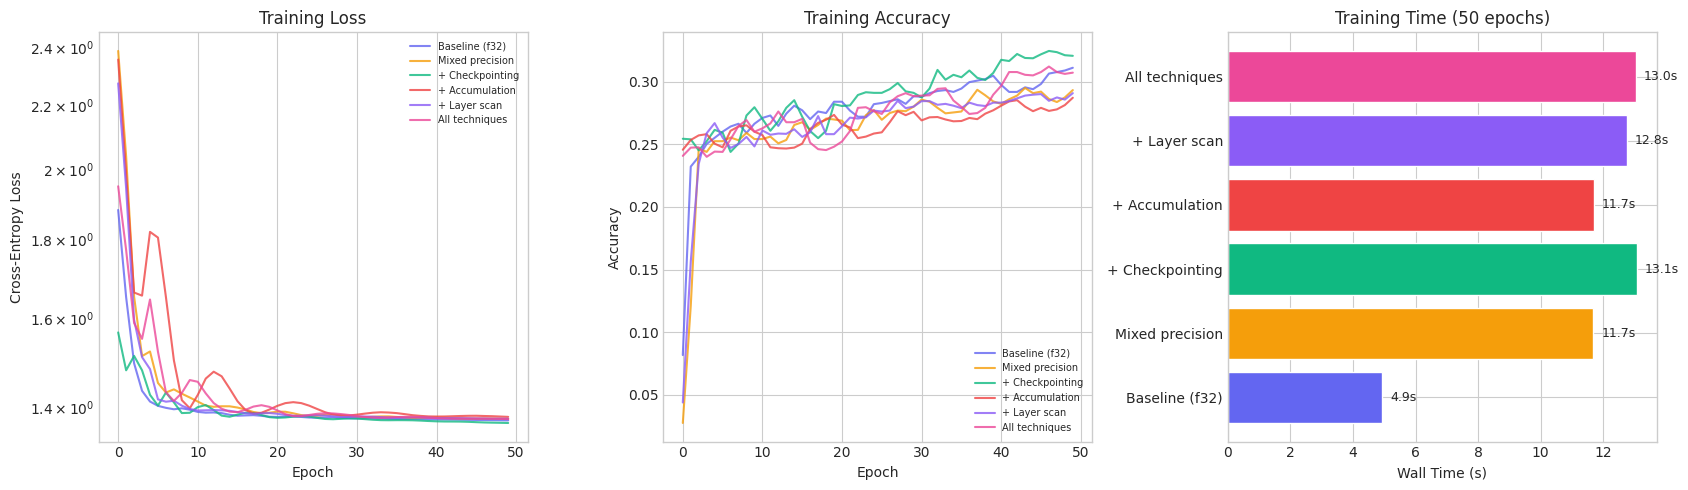

In [18]:
colors_plot = ["#6366f1", "#f59e0b", "#10b981", "#ef4444", "#8b5cf6", "#ec4899"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Training loss
for h, c in zip(histories, colors_plot):
    axes[0].plot(h["train_loss"], color=c, alpha=0.8, label=h["label"], linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Training Loss")
axes[0].set_yscale("log")
axes[0].legend(fontsize=7, loc="upper right")

# Training accuracy
for h, c in zip(histories, colors_plot):
    axes[1].plot(h["train_acc"], color=c, alpha=0.8, label=h["label"], linewidth=1.5)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy")
axes[1].legend(fontsize=7, loc="lower right")

# Timing comparison
labels = [h["label"] for h in histories]
times = [h["elapsed"] for h in histories]
bars = axes[2].barh(labels, times, color=colors_plot, edgecolor="white")
for bar, t in zip(bars, times):
    axes[2].text(bar.get_width() + max(times) * 0.02,
                 bar.get_y() + bar.get_height() / 2,
                 f"{t:.1f}s", va="center", fontsize=9)
axes[2].set_xlabel("Wall Time (s)")
axes[2].set_title(f"Training Time ({NUM_EPOCHS} epochs)")

plt.tight_layout()
plt.show()

---

## 10 — Memory Analysis

Each technique reduces a different component of GPU memory. Here we estimate **activation memory** per training step for our 4-layer transformer with hidden size 128 and batch size 64:

| Component | float32 | bfloat16 | bf16 + remat |
|-----------|---------|----------|--------------|
| QKV projection ($B \times S \times 3Hd$) | $12BSd$ bytes | $6BSd$ bytes | recomputed |
| Attention weights ($B \times h \times S \times S$) | $4BhS^2$ bytes | $2BhS^2$ bytes | recomputed |
| MLP intermediates ($B \times S \times 4H$) | $16BSH$ bytes | $8BSH$ bytes | recomputed |
| Layer input ($B \times S \times H$) | $4BSH$ bytes | $2BSH$ bytes | $2BSH$ (kept) |

With gradient accumulation ($K$ mini-batches), effective $B$ becomes $B/K$, giving another $K\times$ reduction.

Configuration                   Activation Memory  Reduction
------------------------------------------------------------
float32, full batch                      88.00 MB       1.0×
bfloat16, full batch                     52.00 MB       1.7×
bf16 + remat                              4.00 MB      22.0×
bf16 + remat + 4× accum                   1.00 MB      88.0×
bf16 + remat + 8× accum                   0.50 MB     176.0×


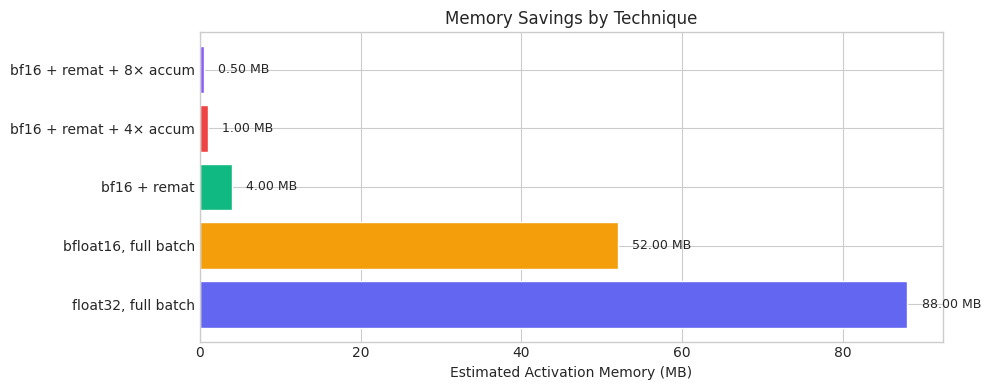

In [19]:
B = BATCH_SIZE
S = SEQ_LEN
H = 128  # hidden_size
n_heads = 4
head_dim = 32
n_layers = 4
mlp_exp = 4

def estimate_activation_memory(batch_size, dtype_bytes, use_remat=False):
    """Estimate activation memory in bytes for the full model."""
    per_layer = 0
    if use_remat:
        # Only store layer input
        per_layer = dtype_bytes * batch_size * S * H
    else:
        # QKV projections
        per_layer += dtype_bytes * batch_size * S * (3 * n_heads * head_dim)
        # Attention weights (always float32 for softmax)
        per_layer += 4 * batch_size * n_heads * S * S
        # MLP intermediates
        per_layer += dtype_bytes * batch_size * S * (mlp_exp * H)
        # Layer input + output
        per_layer += dtype_bytes * batch_size * S * H * 2
    return per_layer * n_layers

configs_mem = [
    ("float32, full batch",          B, 4, False, 1),
    ("bfloat16, full batch",         B, 2, False, 1),
    ("bf16 + remat",                 B, 2, True,  1),
    ("bf16 + remat + 4× accum",      B, 2, True,  4),
    ("bf16 + remat + 8× accum",      B, 2, True,  8),
]

print(f"{'Configuration':<30} {'Activation Memory':>18} {'Reduction':>10}")
print("-" * 60)
baseline_mem = None
mems = []
for name, bs, db, remat, n_acc in configs_mem:
    effective_bs = bs // n_acc
    mem = estimate_activation_memory(effective_bs, db, remat)
    if baseline_mem is None:
        baseline_mem = mem
    reduction = baseline_mem / mem
    mems.append(mem)
    print(f"{name:<30} {mem / 1024**2:>15.2f} MB {reduction:>9.1f}×")

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
labels_mem = [c[0] for c in configs_mem]
colors_mem = ["#6366f1", "#f59e0b", "#10b981", "#ef4444", "#8b5cf6"]
bars = ax.barh(labels_mem, [m / 1024**2 for m in mems],
               color=colors_mem, edgecolor="white")
for bar, m in zip(bars, mems):
    ax.text(bar.get_width() + max(mems) / 1024**2 * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{m / 1024**2:.2f} MB", va="center", fontsize=9)
ax.set_xlabel("Estimated Activation Memory (MB)")
ax.set_title("Memory Savings by Technique")
plt.tight_layout()
plt.show()

---

## Summary

We built a **decoder-only transformer** for DNA sequence modeling and integrated four complementary scaling techniques into a single, configurable architecture:

| Technique | Mechanism | Memory Impact | Speed Impact |
|-----------|-----------|---------------|--------------|
| **Mixed Precision** (bfloat16) | Half-precision activations, full-precision params | ~2× activation reduction | Faster on GPU/TPU (tensor cores) |
| **Gradient Checkpointing** (remat) | Discard & recompute activations in backward | ~90% savings per block | ~30% extra compute |
| **Gradient Accumulation** (scan) | Split batch into $K$ mini-batches, average gradients | $K\times$ activation reduction | $K\times$ slower per step |
| **Layer Scanning** (nn.scan) | Share compiled code across identical layers | Reduces compilation | Slight overhead from `dynamic_slice` |

**Key takeaways**:

- **bfloat16** is a drop-in replacement for float32 — same dynamic range, no loss scaling needed
- **remat** saves memory proportional to network depth — essential for deep transformers
- **Gradient accumulation** simulates arbitrary batch sizes — `jax.lax.scan` compiles a single efficient loop
- **Layer scanning** reduces compilation time for deep models — choose based on model depth
- These techniques **compose multiplicatively** — combining all four enables training models that far exceed single-GPU memory
- **Buffer donation** (`donate_argnames`) is free — always use it for state objects in JIT-compiled functions